In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
sber = pd.read_csv('data/SBRF.txt')

In [3]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    """
  # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """
    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  return result


In [4]:
sber_15_bad = good_dataframe(sber, '15 min')
sber_15 = sber_15_bad.reset_index()
sber_15

,time,open,high,low,close,volume
0,2009-01-11 10:30:00,2301.0,2346.0,2265.0,2340.0,2993
1,2009-01-11 10:45:00,2341.0,2380.0,2340.0,2361.0,4804
2,2009-01-11 11:00:00,2366.0,2369.0,2352.0,2361.0,1660
3,2009-01-11 11:15:00,2360.0,2362.0,2324.0,2347.0,2811
4,2009-01-11 11:30:00,2343.0,2350.0,2338.0,2346.0,425
...,...,...,...,...,...,...
229931,2025-06-30 22:45:00,29853.0,29856.0,29834.0,29838.0,212
229932,2025-06-30 23:00:00,29837.0,29840.0,29825.0,29828.0,266
229933,2025-06-30 23:15:00,29827.0,29865.0,29827.0,29849.0,276
229934,2025-06-30 23:30:00,29849.0,29853.0,29845.0,29845.0,166


# Смещение данных

In [5]:
def shift_features_2_candle(data):
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

df = shift_features_2_candle(sber_15)
df

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00


# Напишем функцию детекции свечного паттерна

In [6]:
def detection_bullish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна."""

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    data['filtr'] = filtr
    return data

In [7]:
df_b = detection_bullish_engulfing_pattern(df)

In [8]:
df_b.head(30)

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,filtr
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,NO
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern,NO
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,NO
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,0,0,bullish_engulfing_pattern,NO
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,NO
6,2346.0,2346,2350.0,2346,2339.0,2344,2352.0,2355,901,773,2009-01-11 12:00:00,2009-01-11 11:45:00,0,0,bullish_engulfing_pattern,NO
7,2350.0,2346,2339.0,2350,2339.0,2339,2354.0,2352,519,901,2009-01-11 12:15:00,2009-01-11 12:00:00,0,0,bullish_engulfing_pattern,NO
8,2340.0,2350,2340.0,2339,2337.0,2339,2344.0,2354,270,519,2009-01-11 12:30:00,2009-01-11 12:15:00,0,0,bullish_engulfing_pattern,NO
9,2338.0,2340,2339.0,2340,2328.0,2337,2340.0,2344,574,270,2009-01-11 12:45:00,2009-01-11 12:30:00,0,0,bullish_engulfing_pattern,NO
10,2335.0,2338,2339.0,2339,2330.0,2328,2340.0,2340,396,574,2009-01-11 13:00:00,2009-01-11 12:45:00,0,0,bullish_engulfing_pattern,NO


Напишем функцию, которая считает прибыль или убыток при входе на цене открытия после завершения паттерна, держит позицию N следующих свечей, где N пробегает [1, 2, ..., 10, 15, 20, ..., 50] и выходит на закрытии последней свечи.

In [9]:
N = 1
df['open_NEW'] = df['open_N'].shift(-N)
df

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,open_NEW
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,2366.0
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,2360.0
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,2343.0
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,2346.0
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,2346.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00,29837.0
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00,29827.0
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00,29849.0
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00,29843.0


In [10]:
def lst_trade_statistics_bul(data, commission=0.001):
   # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
   data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
   # Проходимся циклом по периодам удержания позиции
   all_strategy = []
   for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
      strategy = [] # Список для результатов стратегии
      # Блок для определения цены входа и выхода
      exit_candidate = data['open_N'].shift(-N)
      is_entry = data['signal'] == 1
      entry_price = data['open_N'][is_entry]
      exit_price = exit_candidate[is_entry]
      # Считаем результат
      profit = exit_price - entry_price
      if len(profit) == 0:
         strategy_name = data['strategy'][1]
         filtr = data['filtr'][1]
         all_strategy.append({'strategy' : strategy_name, 'filtr' : filtr, 'N': N, 'trades': 0, 'win_rate': 0.0, 'total_profit': 0.0, 'results': 0})
         continue
      # Чистая прибыль
      profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
      # Статистика
      # Названия
      strategy_name = data['strategy'][1]
      filtr = data['filtr'][1]
      
      all_strategy.append({'strategy' : strategy_name, 'filtr' : filtr,
                           'N' : N,
                           'trades' : len(profit_net),
                           'win_rate' : np.round(np.mean(profit_net > 0), 2),
                           'total_profit' : np.round(np.sum(profit_net), 1),
                           'results' : profit_net})
   return all_strategy

result = lst_trade_statistics_bul(df_b)
result_strategy = pd.DataFrame(result)
result_strategy

,strategy,filtr,N,trades,win_rate,total_profit,results
0,bullish_engulfing_pattern,NO,1,7634,0.47,363.7,"[0.0, -2.002, -3.0029999999999997, 11.988, -13..."
1,bullish_engulfing_pattern,NO,2,7634,0.48,-4941.3,"[-3.0029999999999997, -11.011, -14.014, 18.981..."
2,bullish_engulfing_pattern,NO,3,7634,0.49,-3092.8,"[-12.011999999999999, -10.009999999999998, 0.9..."
3,bullish_engulfing_pattern,NO,4,7634,0.49,-2615.8,"[-14.014, 5.994, 12.987, 5.994, -26.0259999999..."
4,bullish_engulfing_pattern,NO,5,7634,0.49,5135.6,"[-11.011, 4.995, 19.98, 2.997, -34.034, 27.972..."
5,bullish_engulfing_pattern,NO,6,7634,0.50,4980.1,"[-16.016, -3.0029999999999997, 14.985, 15.984,..."
6,bullish_engulfing_pattern,NO,7,7634,0.50,3608.0,"[-15.014999999999999, -4.004, 6.993, 2.997, -4..."
7,bullish_engulfing_pattern,NO,8,7634,0.50,1172.2,"[-11.011, -4.004, 3.996, 5.994, -45.0449999999..."
8,bullish_engulfing_pattern,NO,9,7634,0.51,1340.3,"[-18.017999999999997, -14.014, 16.983, -11.011..."
9,bullish_engulfing_pattern,NO,10,7634,0.51,8642.9,"[-14.014, -16.016, 3.996, -10.009999999999998,..."


<Axes: >

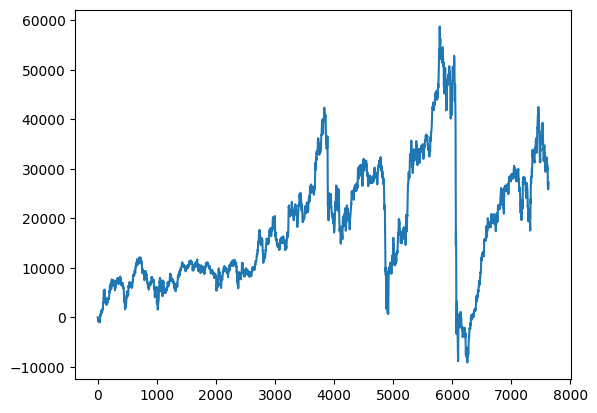

In [11]:
import seaborn as sns
cumsume = np.cumsum(result_strategy.loc[17, 'results'])
sns.lineplot(cumsume)

<Axes: ylabel='close_N'>

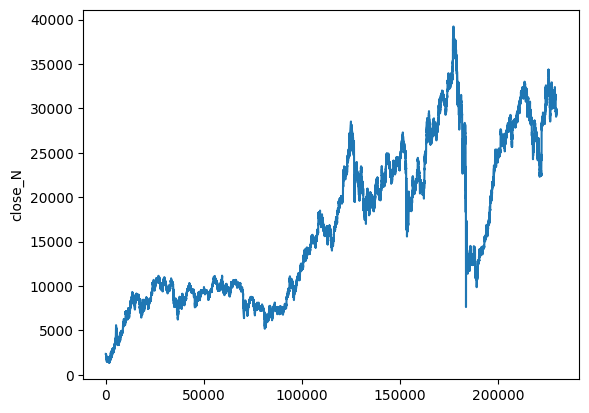

In [12]:
sns.lineplot(df_b['close_N'])

In [13]:
# соединим результаты торгов и датасет
profit_N_10 = result_strategy.loc[2, 'results']
profit_N_10

array([-12.012, -10.01 ,   0.999, ...,  -2.002,  39.96 ,  22.977])

In [14]:
df_b['profit'] = 0
df_b.loc[df_b['pattern'] == 1, 'profit'] = profit_N_10
df_b.head(50)

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,filtr,profit
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,NO,0.000
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern,NO,0.000
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,NO,0.000
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,0,0,bullish_engulfing_pattern,NO,0.000
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,NO,0.000
6,2346.0,2346,2350.0,2346,2339.0,2344,2352.0,2355,901,773,2009-01-11 12:00:00,2009-01-11 11:45:00,0,0,bullish_engulfing_pattern,NO,0.000
7,2350.0,2346,2339.0,2350,2339.0,2339,2354.0,2352,519,901,2009-01-11 12:15:00,2009-01-11 12:00:00,0,0,bullish_engulfing_pattern,NO,0.000
8,2340.0,2350,2340.0,2339,2337.0,2339,2344.0,2354,270,519,2009-01-11 12:30:00,2009-01-11 12:15:00,0,0,bullish_engulfing_pattern,NO,0.000
9,2338.0,2340,2339.0,2340,2328.0,2337,2340.0,2344,574,270,2009-01-11 12:45:00,2009-01-11 12:30:00,0,0,bullish_engulfing_pattern,NO,0.000
10,2335.0,2338,2339.0,2339,2330.0,2328,2340.0,2340,396,574,2009-01-11 13:00:00,2009-01-11 12:45:00,0,0,bullish_engulfing_pattern,NO,0.000


Теперь нам необходимо создать признаки для модели классификации

In [15]:
def features_of_candle(data):
    # 1. Размер тела
    data['body_N'] = data['close_N'] - data['open_N']
    data['body_N-1'] = data['close_N-1'] - data['open_N']
    
    # 2. Размер всей свечи (high - low)
    data['candle_height_N'] = data['high_N'] - data['low_N']
    data['candle_height_N-1'] = data['high_N-1'] - data['low_N-1']
    
    # 3. Верхняя тень
    data['shadow_up_N'] = np.where(
        data['open_N'] < data['close_N'], 
        data['high_N'] - data['close_N'],
        data['high_N'] - data['open_N'])
    
    data['shadow_up_N-1'] = np.where(
        data['open_N-1'] < data['close_N-1'], 
        data['high_N-1'] - data['close_N-1'],
        data['high_N-1'] - data['open_N-1'])
    
    # 4. Нижняя тень
    data['shadow_down_N'] = np.where(
        data['open_N'] < data['close_N'],
        data['open_N'] - data['low_N'],
        data['close_N'] - data['low_N'])
    
    data['shadow_down_N-1'] = np.where(
        data['open_N-1'] < data['close_N-1'],
        data['open_N-1'] - data['low_N-1'],
        data['close_N-1'] - data['low_N-1'])
    
    # 5. Разница между телами (body_N - body_N-1)
    data['body_diff'] = data['body_N'] - data['body_N-1']
    
    # 6. Сумма теней
    data['shadow_sum_N'] = data['shadow_up_N'] + data['shadow_down_N']
    data['shadow_sum_N-1'] = data['shadow_up_N-1'] + data['shadow_down_N-1']
    
    # 7. Отношение верхней тени к телу (логически правильный метод с тремя случаями)
    data['ratio_up_shadow_to_body_N'] = np.where(
    data['body_N'] != 0,
    data['shadow_up_N'] / data['body_N'],
    np.where(
        data['shadow_up_N'] == 0,
        0,
        100))

    data['ratio_up_shadow_to_body_N_abs'] = np.where(
    data['body_N'] != 0,
    np.abs(data['shadow_up_N'] / data['body_N']),
    np.where(
        data['shadow_up_N'] == 0,
        0,
        100))

    data['ratio_up_shadow_to_body_N-1'] = np.where(
    data['body_N-1'] != 0,
    data['shadow_up_N-1'] / data['body_N-1'],
    np.where(
        data['shadow_up_N-1'] == 0,
        0,
        100))

    data['ratio_up_shadow_to_body_N-1_abs'] = np.where(
    data['body_N-1'] != 0,
    np.abs(data['shadow_up_N-1'] / data['body_N-1']),
    np.where(
        data['shadow_up_N-1'] == 0,
        0,
        100))


    # 8. Отношение нижней тени ко всему телу по модулу и просто
    data['ratio_down_shadow_to_body_N'] = np.where(
    data['body_N'] != 0,
    data['shadow_down_N'] / data['body_N'],
    np.where(
        data['shadow_down_N'] == 0,
        0,
        100))

    data['ratio_down_shadow_to_body_N_abs'] = np.where(
    data['body_N'] != 0,
    np.abs(data['shadow_down_N'] / data['body_N']),
    np.where(
        data['shadow_down_N'] == 0,
        0,
        100))

    data['ratio_down_shadow_to_body_N-1'] = np.where(
    data['body_N-1'] != 0,
    data['shadow_down_N-1'] / data['body_N-1'],
    np.where(
        data['shadow_down_N-1'] == 0,
        0,
        100))

    data['ratio_down_shadow_to_body_N-1_abs'] = np.where(
    data['body_N-1'] != 0,
    np.abs(data['shadow_down_N-1'] / data['body_N-1']),
    np.where(
        data['shadow_down_N-1'] == 0,
        0,
        100))
    
    # 9. Отношение суммы теней ко всему телу по модулу и просто
    data['ratio_sum_shadow_to_body_N'] = np.where(
    data['body_N'] != 0,
    data['shadow_sum_N'] / data['body_N'],
    np.where(
        data['shadow_sum_N'] == 0,
        0,
        100))

    data['ratio_sum_shadow_to_body_N_abs'] = np.where(
    data['body_N'] != 0,
    np.abs(data['shadow_sum_N'] / data['body_N']),
    np.where(
        data['shadow_sum_N'] == 0,
        0,
        100))

    data['ratio_sum_shadow_to_body_N-1'] = np.where(
    data['body_N-1'] != 0,
    data['shadow_sum_N-1'] / data['body_N-1'],
    np.where(
        data['shadow_sum_N-1'] == 0,
        0,
        100))

    data['ratio_sum_shadow_to_body_N-1_abs'] = np.where(
    data['body_N-1'] != 0,
    np.abs(data['shadow_sum_N-1'] / data['body_N-1']),
    np.where(
        data['shadow_sum_N-1'] == 0,
        0,
        100))
    
    # 10. Насколько % одна свеча перекрывает другую. Будем смотреть относительно тела N
    data['ratio_of_body'] = np.where(((data['body_N'] != 0) &  (data['body_N-1'] != 0)), 
                                     data['body_N'] / data['body_N-1'], 0)
                                     
    data['ratio_of_body_abs'] = np.where(((data['body_N'] != 0) &  (data['body_N-1'] != 0)), 
                                     np.abs(data['body_N'] / data['body_N-1']), 0)
    
    # 11. Флаг, если тело = 0 
    data['is_zero_body_N'] = (data['body_N'] == 0).astype(int)
    data['is_zero_body_N-1'] = (data['body_N-1'] == 0).astype(int)

    return data


In [16]:
df_full = features_of_candle(df_b)

In [17]:
df_full

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,...,ratio_down_shadow_to_body_N-1,ratio_down_shadow_to_body_N-1_abs,ratio_sum_shadow_to_body_N,ratio_sum_shadow_to_body_N_abs,ratio_sum_shadow_to_body_N-1,ratio_sum_shadow_to_body_N-1_abs,ratio_of_body,ratio_of_body_abs,is_zero_body_N,is_zero_body_N-1
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,...,-36.00,36.00,1.000000,1.000000,-42.00,42.00,-20.000,20.000,0,0
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,...,-0.20,0.20,-2.400000,2.400000,-4.00,4.00,1.000,1.000,0,0
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,...,9.00,9.00,-1.923077,1.923077,12.00,12.00,-13.000,13.000,0,0
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,...,5.75,5.75,3.000000,3.000000,6.25,6.25,0.750,0.750,0,0
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,...,100.00,100.00,100.000000,100.000000,100.00,100.00,0.000,0.000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,...,-0.00,0.00,-0.466667,0.466667,-0.50,0.50,1.875,1.875,0,0
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,...,4.00,4.00,-0.666667,0.666667,7.00,7.00,-9.000,9.000,0,0
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,...,3.00,3.00,0.727273,0.727273,6.00,6.00,22.000,22.000,0,0
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,...,0.00,0.00,-1.000000,1.000000,100.00,100.00,0.000,0.000,0,1


In [18]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229935 entries, 1 to 229935
Data columns (total 44 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   open_N                             229935 non-null  float64       
 1   open_N-1                           229935 non-null  int32         
 2   close_N                            229935 non-null  float64       
 3   close_N-1                          229935 non-null  int32         
 4   low_N                              229935 non-null  float64       
 5   low_N-1                            229935 non-null  int32         
 6   high_N                             229935 non-null  float64       
 7   high_N-1                           229935 non-null  int32         
 8   volume_N                           229935 non-null  int64         
 9   volume_N-1                         229935 non-null  int32         
 10  time_N                   

In [19]:
df_full.drop(['signal', 'strategy', 'time_N', 'time_N-1', 'filtr'], axis=1, inplace=True)

In [20]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229935 entries, 1 to 229935
Data columns (total 39 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   open_N                             229935 non-null  float64
 1   open_N-1                           229935 non-null  int32  
 2   close_N                            229935 non-null  float64
 3   close_N-1                          229935 non-null  int32  
 4   low_N                              229935 non-null  float64
 5   low_N-1                            229935 non-null  int32  
 6   high_N                             229935 non-null  float64
 7   high_N-1                           229935 non-null  int32  
 8   volume_N                           229935 non-null  int64  
 9   volume_N-1                         229935 non-null  int32  
 10  pattern                            229935 non-null  int64  
 11  profit                             229935 no

In [21]:
df_full['target'] = np.where(df_full['profit'] > 0, 1, 0)

In [22]:
df_full[df_full['target'] == 1][['target', 'profit', 'pattern']]

,target,profit,pattern
153,1,0.999,1
156,1,13.986,1
349,1,37.962,1
450,1,50.949,1
708,1,47.952,1
...,...,...,...
229600,1,40.959,1
229646,1,28.971,1
229678,1,25.974,1
229824,1,39.960,1


# **Модель машинного обучения**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold

In [ ]:
# # Подготовка данных
# X = df_rolling.drop('target', axis=1)
# y = df_rolling['target']
# X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, stratify=y)

ValueError: Input y contains NaN.

## 1. Модель логистической регрессии

Основные параметры LogisticRegression:

* random_state — число, на основе которого происходит генерация случайных чисел.
* penalty — метод регуляризации. Возможные значения:
    * 'l1' — L1-регуляризация;
    * 'l2' — L2-регуляризация (используется по умолчанию);
    * 'elasticnet' — эластичная сетка (L1+L2);
    * None — отсутствие регуляризации.
* C — коэффициент обратный коэффициенту регуляризации, то есть равен . Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* solver — численный метод оптимизации функции потерь logloss, может быть:
    * 'sag' — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * 'saga' — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * 'newton-cg' — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * 'lbfgs' — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * 'liblinear' — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* max_iter — максимальное количество итераций, выделенных на сходимость.

In [ ]:
# Кросс-валидация
# kf = model_selection.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
# # 
# cv_metrcis = model_selection.cross_validate(
#     estimator=LogisticRegression(),
#     cv=kf,
#     X=X_train,
#     y=y_train,
#     scoring=('f1', 'accuracy', 'recall', 'precision'))

# # Смотрим результаты
# print(f'Среднее значение F1-score на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_f1']), 2)}')
# print(f'Среднее значение accuracy на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_accuracy']), 2)}')
# print(f'Среднее значение recall на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_recall']), 2)}')
# print(f'Среднее значение precision на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_precision']), 2)}')

# # Расчитываем показатели на тестовой выборке 
# log_reg = LogisticRegression()
# log_reg.fit(X_train, y_train)
# y_pred_log_reg = log_reg.predict(X_test)

# # Смотрим результаты
# print(f'\nЗначение F1-score на тестовой выборке: {np.round(np.mean(metrics.f1_score(y_test, y_pred_log_reg)), 2)}')
# print(f'Значение accuracy на тестовой выборке: {np.round(np.mean(metrics.accuracy_score(y_test, y_pred_log_reg)), 2)}')
# print(f'Значение recall на тестовой выборке: {np.round(np.mean(metrics.recall_score(y_test, y_pred_log_reg)), 2)}')
# print(f'Значение precision на тестовой выборке: {np.round(np.mean(metrics.precision_score(y_test, y_pred_log_reg)), 2)}')

Среднее значение F1-score на валидационных фолдах: 0.26
Среднее значение accuracy на валидационных фолдах: 0.51
Среднее значение recall на валидационных фолдах: 0.17
Среднее значение precision на валидационных фолдах: 0.5

Значение F1-score на тестовой выборке: 0.22
Значение accuracy на тестовой выборке: 0.5
Значение recall на тестовой выборке: 0.14
Значение precision на тестовой выборке: 0.46


In [ ]:
#  #Создаём объект кросс-валидатора 
# kf = model_selection.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# # Считаем метрики на кросс-валидации
# cv_metrics = model_selection.cross_validate(
#     estimator=log_reg,
#     X = X_train,
#     y = y_train,
#     cv=kf,
#     scoring='f1',
#     return_train_score=True
# )
# display(cv_metrics)
# print(f'Среднее значение F1-score на валидационных фолдах: {np.round(np.mean(cv_metrics['test_score']), 3)}')
# print(f'Значение F1-score на тестовой выборке {np.round(metrics.f1_score(y_test, y_predict_test), 3)}')